In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

=== BAGIAN A: Membaca & Konversi Warna ===
Citra 1:
  - Ukuran (Shape)  : (267, 257, 3)
  - Tipe Data       : uint8
  - Nilai Min Pixel : 0
  - Nilai Max Pixel : 255
Citra 2:
  - Ukuran (Shape)  : (588, 735, 3)
  - Tipe Data       : uint8
  - Nilai Min Pixel : 0
  - Nilai Max Pixel : 255


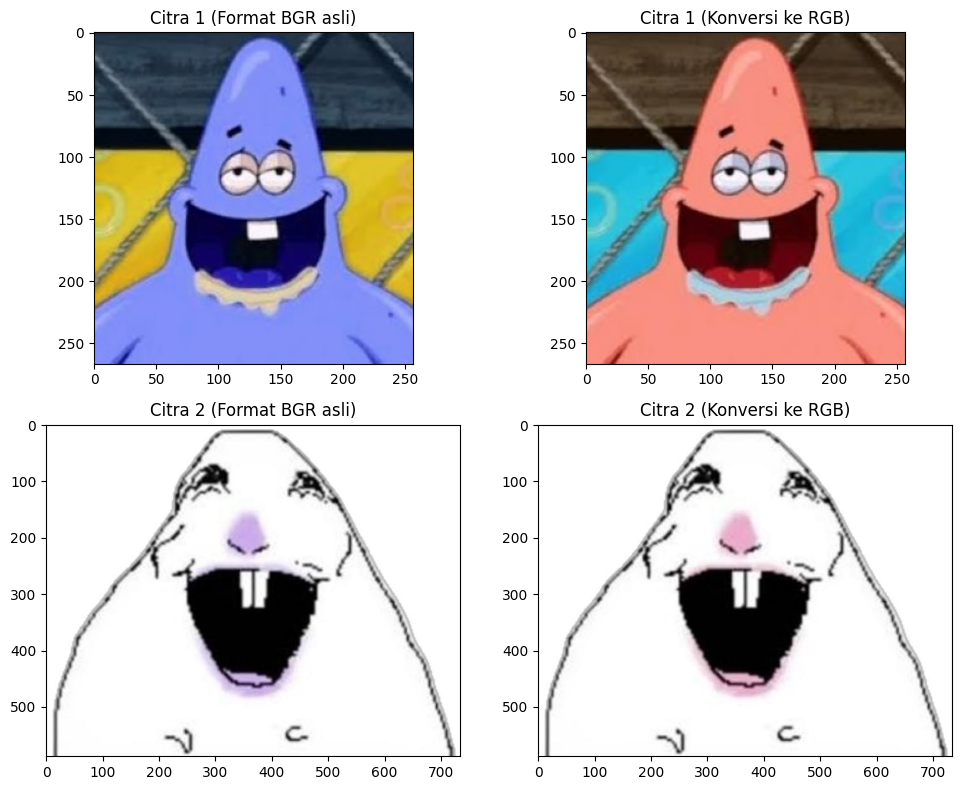

In [2]:
print("=== BAGIAN A: Membaca & Konversi Warna ===")
# 1. Membaca citra asli (Format BGR bawaan OpenCV)
img1 = cv.imread("images/image1.jpg")
img2 = cv.imread("images/image2.jpg")

# 2. Konversi warna BGR ke RGB untuk visualisasi Matplotlib
img1_rgb = cv.cvtColor(img1, cv.COLOR_BGR2RGB)
img2_rgb = cv.cvtColor(img2, cv.COLOR_BGR2RGB)

# 3. Menampilkan informasi citra
for i, img in enumerate([img1_rgb, img2_rgb], 1):
    print(f"Citra {i}:")
    print(f"  - Ukuran (Shape)  : {img.shape}")
    print(f"  - Tipe Data       : {img.dtype}")
    print(f"  - Nilai Min Pixel : {np.min(img)}")
    print(f"  - Nilai Max Pixel : {np.max(img)}")

# Plot perbandingan BGR vs RGB
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes[0, 0].imshow(img1)  # Menampilkan BGR di Matplotlib (akan terlihat salah)
axes[0, 0].set_title("Citra 1 (Format BGR asli)")
axes[0, 1].imshow(img1_rgb)
axes[0, 1].set_title("Citra 1 (Konversi ke RGB)")

axes[1, 0].imshow(img2)
axes[1, 0].set_title("Citra 2 (Format BGR asli)")
axes[1, 1].imshow(img2_rgb)
axes[1, 1].set_title("Citra 2 (Konversi ke RGB)")
plt.tight_layout()
plt.show()

In [3]:
print("\n=== BAGIAN B: Resize Citra ===")
# Ukuran target disamakan menjadi 600x400 piksel
target_size = (600, 400)
img1_resize = cv.resize(img1_rgb, target_size)
img2_resize = cv.resize(img2_rgb, target_size)

print(f"Ukuran Citra 1 Setelah Resize : {img1_resize.shape}")
print(f"Ukuran Citra 2 Setelah Resize : {img2_resize.shape}")


=== BAGIAN B: Resize Citra ===
Ukuran Citra 1 Setelah Resize : (400, 600, 3)
Ukuran Citra 2 Setelah Resize : (400, 600, 3)



=== BAGIAN C: Image Blending ===


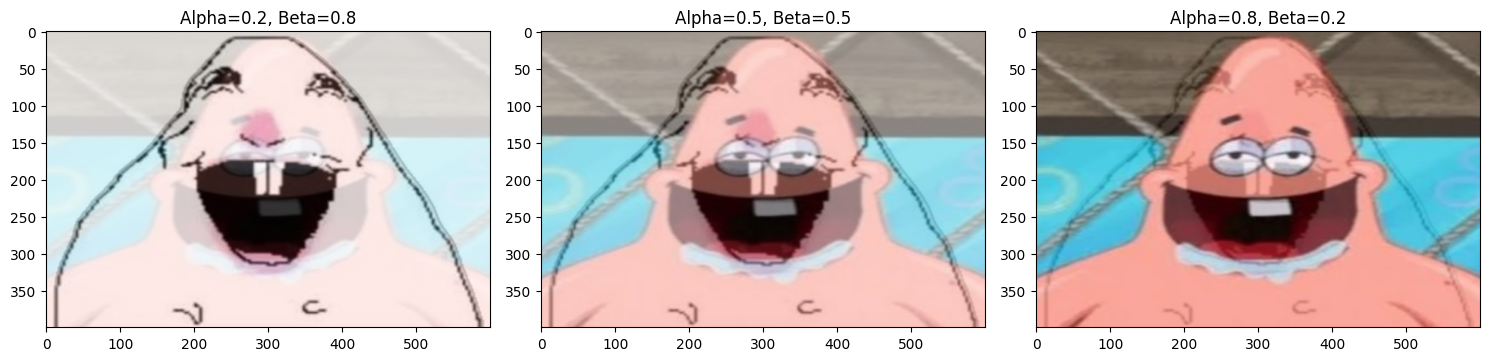

In [4]:
print("\n=== BAGIAN C: Image Blending ===")
# Eksperimen 3 kombinasi bobot (alpha + beta = 1, gamma = 0)
weights = [(0.2, 0.8), (0.5, 0.5), (0.8, 0.2)]
blend_results = []

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for idx, (alpha, beta) in enumerate(weights):
    img_blend = cv.addWeighted(img1_resize, alpha, img2_resize, beta, 0)
    blend_results.append(img_blend)
    axes[idx].imshow(img_blend)
    axes[idx].set_title(f"Alpha={alpha}, Beta={beta}")
plt.tight_layout()
plt.show()


=== BAGIAN D: Image Negative ===


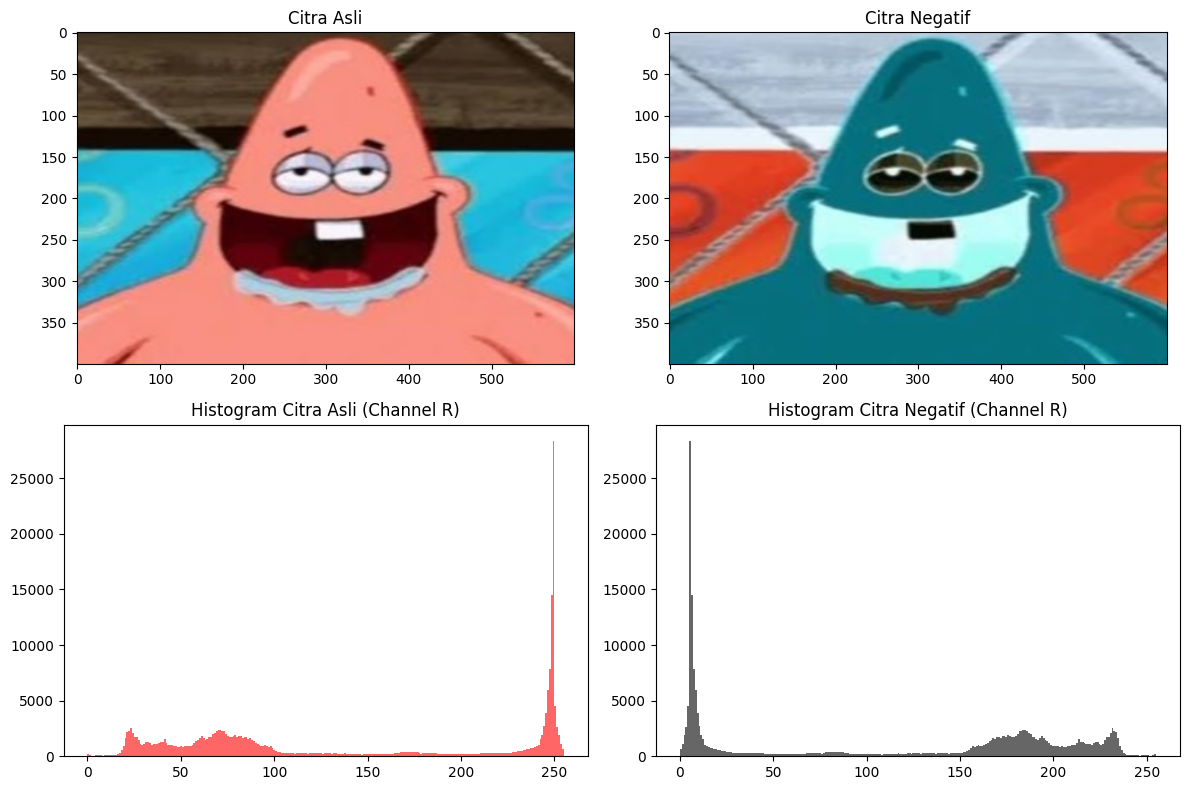

In [5]:
print("\n=== BAGIAN D: Image Negative ===")
# Persamaan: s = 255 - r
img1_negative = 255 - img1_resize

# Plot Citra dan Histogram
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0, 0].imshow(img1_resize)
axes[0, 0].set_title("Citra Asli")
axes[0, 1].imshow(img1_negative)
axes[0, 1].set_title("Citra Negatif")

# Histogram Citra Asli (R channel sebagai contoh)
axes[1, 0].hist(img1_resize[:,:,0].ravel(), bins=256, color='red', alpha=0.6)
axes[1, 0].set_title("Histogram Citra Asli (Channel R)")

# Histogram Citra Negatif
axes[1, 1].hist(img1_negative[:,:,0].ravel(), bins=256, color='black', alpha=0.6)
axes[1, 1].set_title("Histogram Citra Negatif (Channel R)")
plt.tight_layout()
plt.show()


=== BAGIAN E: Transformasi Logaritmik ===
Sebelum Log -> Min: 0, Max: 255
Sesudah Log -> Min: 0, Max: 0


C:\Temp\ipykernel_8404\2364223091.py:4: RuntimeWarning: overflow encountered in scalar add
  c_log = 255 / np.log10(1 + r_max)
C:\Temp\ipykernel_8404\2364223091.py:4: RuntimeWarning: divide by zero encountered in log10
  c_log = 255 / np.log10(1 + r_max)


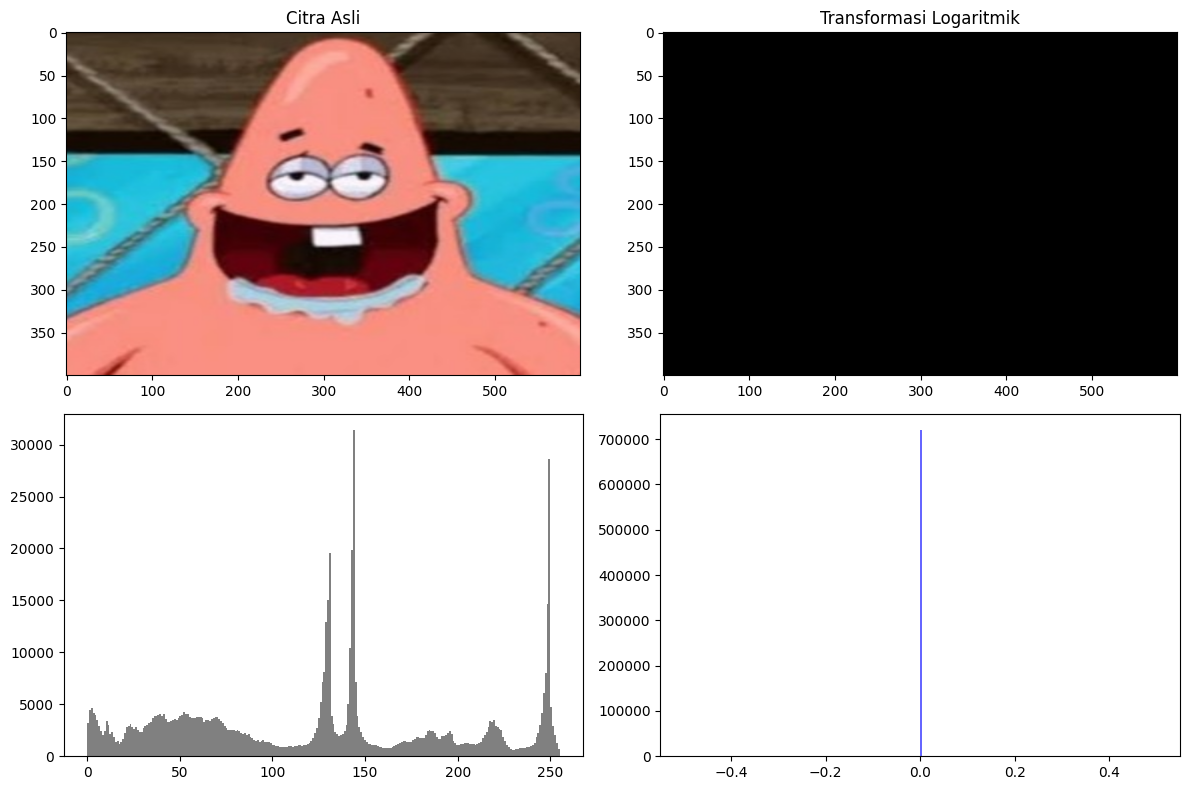

In [6]:
print("\n=== BAGIAN E: Transformasi Logaritmik ===")
# Hitung konstanta c dinamis berdasarkan r_max
r_max = np.max(img1_resize)
c_log = 255 / np.log10(1 + r_max)

# Terapkan rumus s = c * log(1 + r)
img_log = c_log * np.log10(img1_resize.astype(np.float64) + 1)
img_log = np.array(img_log, dtype=np.uint8)

print(f"Sebelum Log -> Min: {np.min(img1_resize)}, Max: {np.max(img1_resize)}")
print(f"Sesudah Log -> Min: {np.min(img_log)}, Max: {np.max(img_log)}")

# Plot Log Transform & Histogram
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0, 0].imshow(img1_resize)
axes[0, 0].set_title("Citra Asli")
axes[0, 1].imshow(img_log)
axes[0, 1].set_title("Transformasi Logaritmik")
axes[1, 0].hist(img1_resize.ravel(), bins=256, color='gray')
axes[1, 1].hist(img_log.ravel(), bins=256, color='blue', alpha=0.6)
plt.tight_layout()
plt.show()


=== BAGIAN F: Transformasi Gamma ===


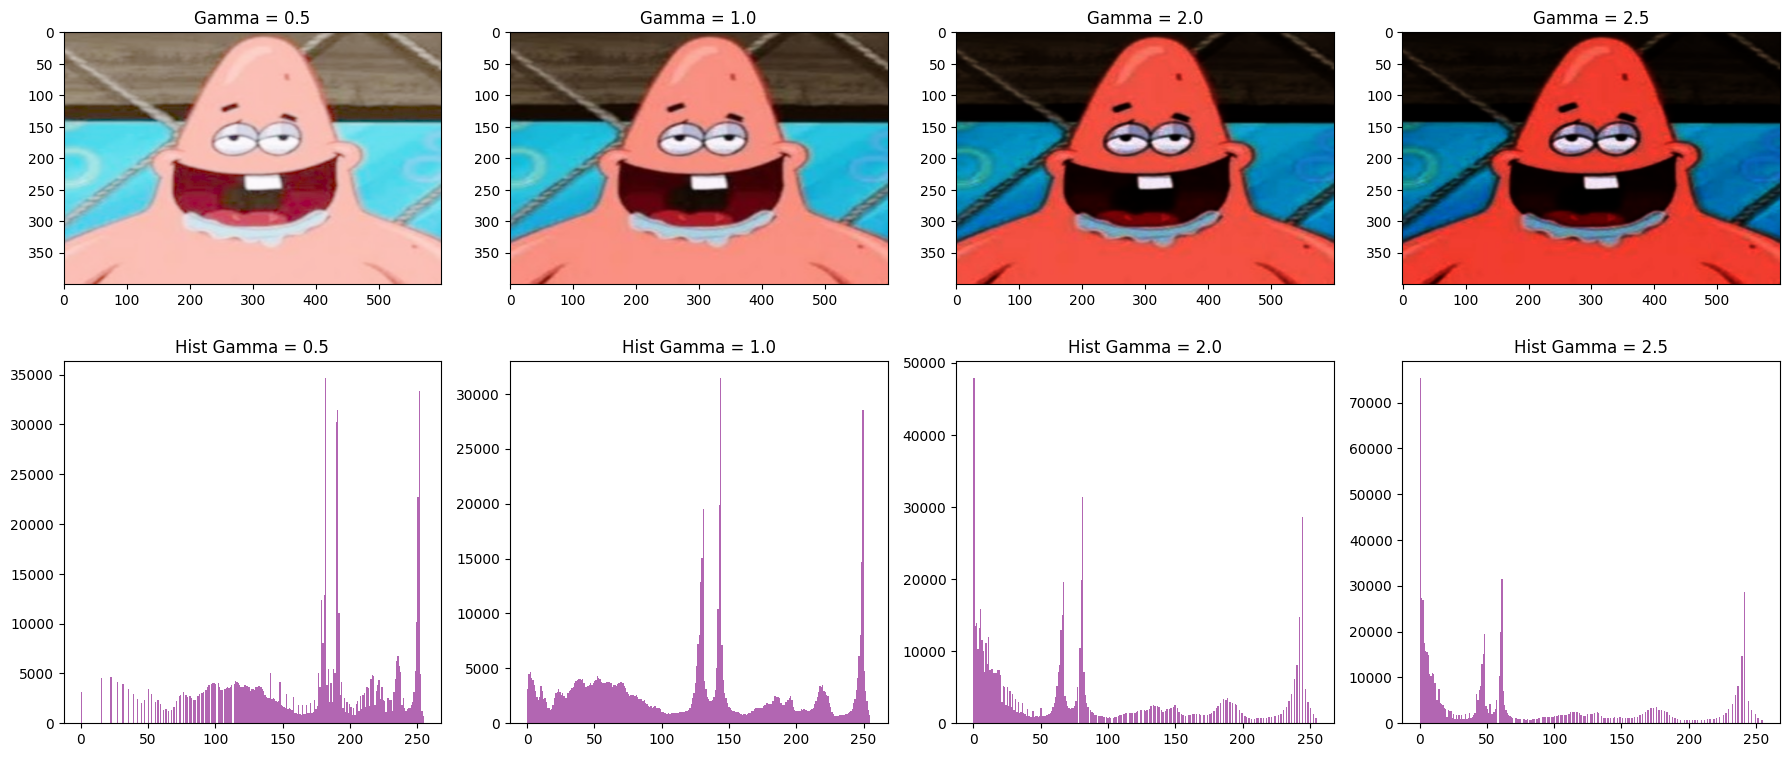

In [7]:
print("\n=== BAGIAN F: Transformasi Gamma ===")
gammas = [0.5, 1.0, 2.0, 2.5]
fig, axes = plt.subplots(2, 4, figsize=(18, 8))

# Normalisasi pixel ke rentang [0, 1]
img_normalized = img1_resize / 255.0

for idx, gamma in enumerate(gammas):
    # Rumus s = r ^ gamma
    img_gamma = np.power(img_normalized, gamma)
    # Kembalikan ke rentang [0, 255]
    img_gamma_out = np.array(img_gamma * 255, dtype=np.uint8)
    
    # Plot Visual
    axes[0, idx].imshow(img_gamma_out)
    axes[0, idx].set_title(f"Gamma = {gamma}")
    
    # Plot Histogram
    axes[1, idx].hist(img_gamma_out.ravel(), bins=256, color='purple', alpha=0.6)
    axes[1, idx].set_title(f"Hist Gamma = {gamma}")

plt.tight_layout()
plt.show()